# How People Use an LLM for Weddings — Insights from WildChat

## Executive Summary

We analyzed the **full WildChat dataset** (~529k real human–ChatGPT conversations, ~284k English) to understand how people actually use an AI assistant for weddings, then distilled a **validated set of 157 genuine wedding conversations** for close study. Four things stand out:

- **Wedding *words* mostly aren't wedding *usage*.** Only ~6% of conversations containing wedding vocabulary are actually about real weddings — the rest are fan-fiction, online-store product listings, and honeymoon travel. *A brand monitoring "wedding" mentions with keywords alone is reading ~50% fan-fiction.*
- **The #1 job people hire AI for is writing, not planning.** The dominant requests are **vows, speeches/toasts, invitations, and thank-you messages** — not budgets, checklists, or logistics. Most "AI wedding planner" products lead with the planning features people use *least*.
- **People iterate most on the words that get read aloud or sent to others.** The longest back-and-forths are about personal wording (messages, invitations) and money (budgets) — the high-stakes moments where "good enough" isn't good enough.
- **There's an open commerce opportunity.** People did *not* bring vendor, venue, or budget *decisions* to a general AI — a gap a trusted, wedding-specific assistant with real data could fill.

> **How confident should you be?** These are **directional** findings from a deliberately high-precision sample (n=157, 2023 data) — strong enough to shape strategy and prioritize bets, but not to size a market. See [`REPORT.md`](../REPORT.md) for full business implications (by player type) and a roadmap to scale this into statistically robust evidence.

---

*The rest of this notebook reproduces the analysis end-to-end from cached artifacts in `data/`.*

# WildChat × Weddings — How people use an LLM for weddings

**Question:** Within a large, real-world corpus of human–ChatGPT conversations
([allenai/WildChat](https://huggingface.co/datasets/allenai/WildChat)), what do
people actually do with the assistant when the topic is *weddings* — and what does
that imply for a wedding-adjacent brand?

This notebook is fully reproducible from the cached artifacts in `data/`. The heavy
extraction (full-dataset stream + embedding) is done by the `scripts/phase*.py`
pipeline; here we load its outputs and analyze.

**Pipeline (3-stage precision funnel):**
1. **Stage 0 — Profiling & feasibility:** stream-sample WildChat, confirm schema,
   measure wedding prevalence vs. other industries.
2. **Stage 1 — Lexical recall:** full-dataset scan; keep English conversations whose
   *user* text hits a wedding lexicon (strong vs. weak terms).
3. **Stage 2 — Semantic precision:** embed candidates (SBERT) and classify by
   **nearest competing prototype** (wedding / fiction-roleplay / e-commerce /
   travel / relationship / generic). Keep only wedding-nearest, strong-term hits.
4. **Stage 3 — Validation:** manual spot-check + cluster inspection.


In [1]:
import json, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd())=="notebooks" else os.getcwd()
DATA = os.path.join(ROOT, "data")
def load_json(name):
    with open(os.path.join(DATA, name)) as f: return json.load(f)
phase0 = load_json("phase0_summary.json")
multi  = load_json("phase0_multitopic_summary.json")
phase1 = load_json("phase1_summary.json")
phase2 = load_json("phase2_summary.json")
res    = load_json("analysis_results.json")
print("Loaded pipeline artifacts.")

Loaded pipeline artifacts.


## 1. Dataset profile (English sample)

Schema and high-level stats from the streamed English sample.

In [2]:
print("English share of streamed:", phase0["english_share_of_streamed"])
print("Model split:", phase0["model_split"])
print("Turns (mean/median/p90):", phase0["turns"]["mean"], phase0["turns"]["median"], phase0["turns"]["p90"])
print("Multi-turn share:", phase0["turns"]["multi_turn_share"])
print("Timestamp range (sample):", phase0["timestamp_range"])

English share of streamed: 0.5161
Model split: {'gpt-4': 13931, 'gpt-3.5-turbo': 16069}
Turns (mean/median/p90): 2.541 1.0 6.0
Multi-turn share: 0.4514
Timestamp range (sample): {'min': '2023-04-10 00:01:08+00:00', 'max': '2023-05-03 12:39:56+00:00'}


## 2. Why weddings? — feasibility across industries

Before committing, we measured strict-lexical prevalence of several brand-relevant
domains over an 80k English sample. Weddings are a mid-volume, high-commerce-intent
niche.

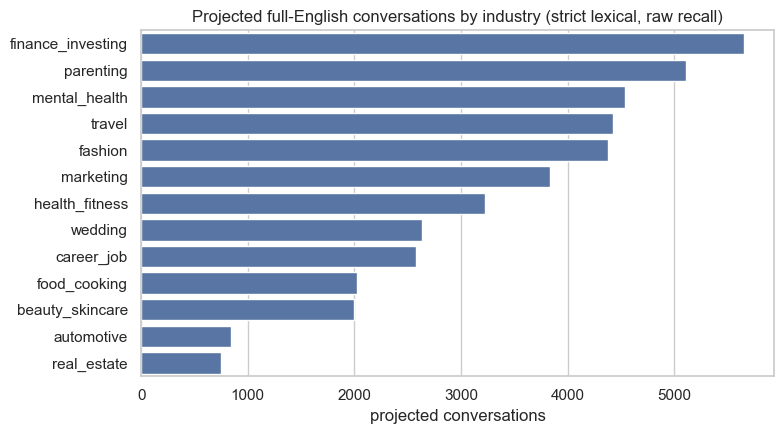

,topic,matches,rate_pct,proj_full_english
0,finance_investing,1313,1.641,5654
1,parenting,1187,1.484,5111
2,mental_health,1055,1.319,4543
3,travel,1027,1.284,4422
4,fashion,1018,1.272,4383
5,marketing,891,1.114,3836
6,health_fitness,749,0.936,3225
7,wedding,611,0.764,2631
8,career_job,599,0.749,2579
9,food_cooking,470,0.588,2023


In [3]:
topics = pd.DataFrame(multi["topics"]).sort_values("matches", ascending=False)
plt.figure(figsize=(8,4.5))
sns.barplot(data=topics, x="proj_full_english", y="topic", color="#4c72b0")
plt.title("Projected full-English conversations by industry (strict lexical, raw recall)")
plt.xlabel("projected conversations"); plt.ylabel("")
plt.tight_layout(); plt.show()
topics[["topic","matches","rate_pct","proj_full_english"]]

## 3. The funnel — recall then precision

The full-dataset scan found many lexical candidates, but most are **not** real wedding
usage. The contrastive classifier routes them to the right bucket.

Full scan: 529,428 convs streamed, 284,168 English
Stage 1 lexical candidates: 6,458 loose / 1,845 strict


/var/folders/35/mq6qzx3d7hz2sc3rndcbxfg80000gp/T/ipykernel_85008/1969287905.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=s.values, y=s.index, palette="rocket")


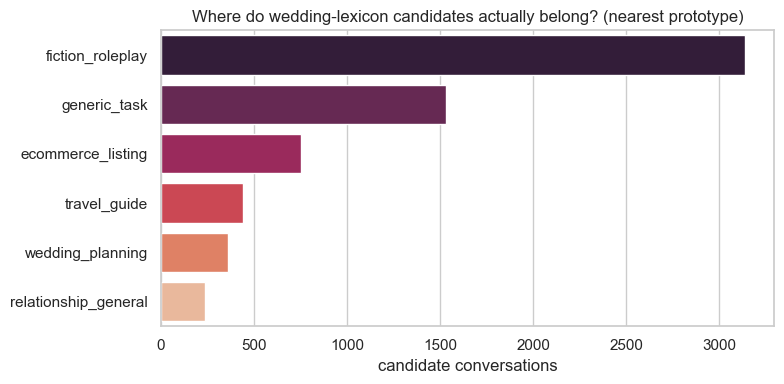

Wedding-relevant after Stage 2 (+strict, sim>=0.30): 157


In [4]:
print(f"Full scan: {phase1['records_streamed']:,} convs streamed, "
      f"{phase1['english_records']:,} English")
print(f"Stage 1 lexical candidates: {phase1['candidates_loose']:,} loose / "
      f"{phase1['candidates_strict']:,} strict")
counts = phase2["nearest_proto_counts"]
s = pd.Series(counts).sort_values(ascending=False)
plt.figure(figsize=(8,4))
sns.barplot(x=s.values, y=s.index, palette="rocket")
plt.title("Where do wedding-lexicon candidates actually belong? (nearest prototype)")
plt.xlabel("candidate conversations"); plt.ylabel("")
plt.tight_layout(); plt.show()
print(f"Wedding-relevant after Stage 2 (+strict, sim>=0.30): {phase2['wedding_relevant']:,}")

### Key finding #1 — Wedding *words* mostly aren't wedding *usage*

Of the wedding-lexicon candidates, the **plurality are fiction/roleplay** (characters
who "get married" — e.g. Doki Doki Literature Club and Minecraft roleplay), plus large
shares of **e-commerce product listings** ("bridal" jewelry to translate/optimize),
**travel guides** (honeymoon destinations), and **generic tasks**. Only a minority are
genuine wedding planning/advice/content. *Lexical filters alone would be ~30% precise.*

## 4. The validated wedding subset — what people ask for

Intent taxonomy over the high-precision subset.

Wedding conversations: 157


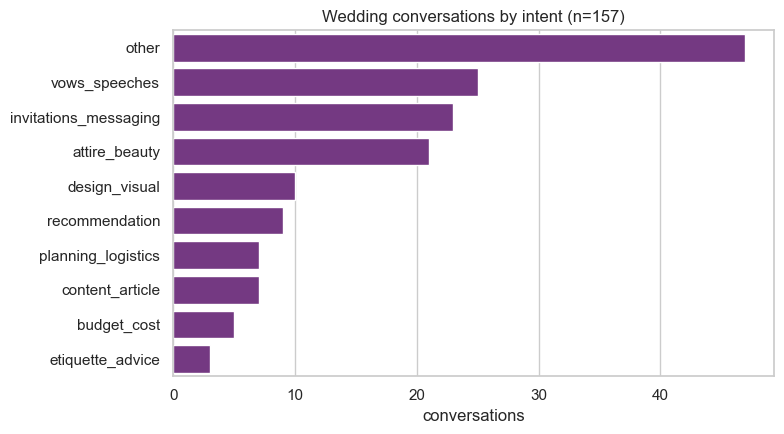

other                    47
vows_speeches            25
invitations_messaging    23
attire_beauty            21
design_visual            10
recommendation            9
planning_logistics        7
content_article           7
budget_cost               5
etiquette_advice          3
dtype: int64

In [5]:
w = pd.read_parquet(os.path.join(DATA, "wedding_final.parquet"))
print("Wedding conversations:", len(w))
ic = pd.Series(res["intent_counts"]).sort_values(ascending=False)
plt.figure(figsize=(8,4.5))
sns.barplot(x=ic.values, y=ic.index, color="#7b2d8e")
plt.title(f"Wedding conversations by intent (n={len(w)})")
plt.xlabel("conversations"); plt.ylabel(""); plt.tight_layout(); plt.show()
ic

### Key finding #2 — It's a **text-generation** tool, not a planner

The dominant intents are **writing tasks**: vows/speeches/toasts, invitation &
thank-you messaging, and captions/blog content. Operational planning (budgets,
checklists, logistics, etiquette) is comparatively rare. People bring the assistant
in to *write wedding words*, not to *project-manage the wedding*.

## 5. Sub-topics (TF-IDF + KMeans)

In [6]:
for cid, terms in res["cluster_terms"].items():
    print(f"Cluster {cid} (n={res['cluster_sizes'][cid]}): {', '.join(terms[:8])}")

Cluster 0 (n=19): captions, best, short, hi, try, ring, generate, happy
Cluster 1 (n=43): rewrite, blog, wedding blog, rewrite wedding, card, love, venue, guests
Cluster 2 (n=50): plan, friend, note, idea, gift, bride, wedding gift, copy
Cluster 3 (n=17): message, thank, role, honeymoon, successful, opportunity, member, hi
Cluster 4 (n=8): ar, prompt, detailed, description, prompts, detailed description, imagine prompt, imagine
Cluster 5 (n=20): groom, speech, father, write wedding, bride, father bride, funny, wedding speech


## 6. Engagement — where conversations get deep

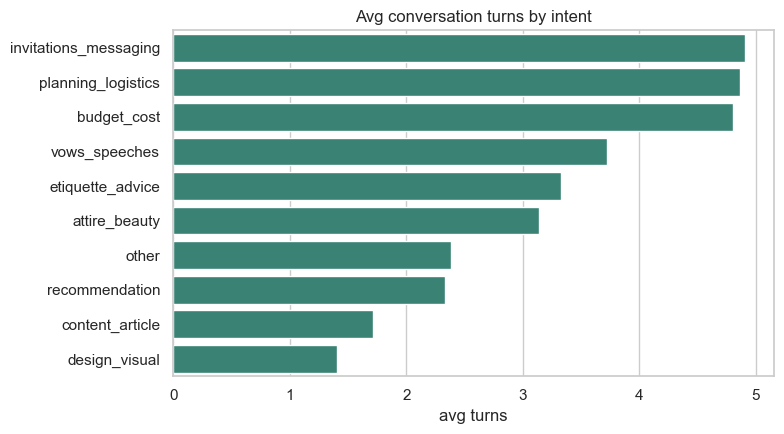

Overall turns: {'mean': 3.18, 'median': 1.0, 'p90': 7.400000000000006}


In [7]:
tbi = pd.Series(res["turns_by_intent"]).sort_values(ascending=False)
plt.figure(figsize=(8,4.5))
sns.barplot(x=tbi.values, y=tbi.index, color="#2d8e7b")
plt.title("Avg conversation turns by intent"); plt.xlabel("avg turns"); plt.ylabel("")
plt.tight_layout(); plt.show()
print("Overall turns:", res["turns_overall"])

### Key finding #3 — Iteration happens on *personal, high-stakes* text

The longest back-and-forths are **messaging/invitations, planning, and budgets** —
tasks where wording is personal or details must be right. One-shot intents
(design/Midjourney prompts, short articles, recommendations) end quickly. Depth is a
proxy for *where the assistant is trusted to get it right* and where users invest effort.

## 7. Temporal volume

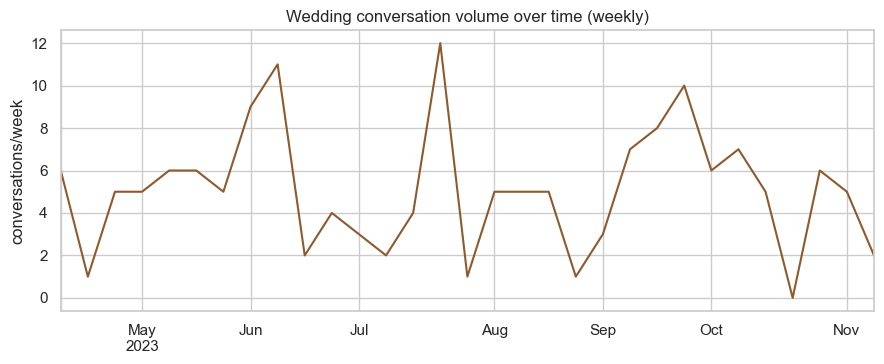

Date range: {'min': '2023-04-11 05:25:08+00:00', 'max': '2023-11-09 10:53:15+00:00'}


In [8]:
w["ts"] = pd.to_datetime(w["timestamp"], errors="coerce", utc=True)
by_week = w.set_index("ts").resample("W").size()
plt.figure(figsize=(9,3.8)); by_week.plot(color="#8e5a2d")
plt.title("Wedding conversation volume over time (weekly)"); plt.ylabel("conversations/week"); plt.xlabel("")
plt.tight_layout(); plt.show()
print("Date range:", res["date_range"])

## 8. Example conversations (qualitative)

In [9]:
for t in w.sort_values("sim_wedding_planning", ascending=False)["user_text"].head(6):
    print("•", " ".join(str(t).split())[:160], "\n")

• suggest a wedding plan 

• help me draft a wedding plan 

• write me an officiant address for a wedding. write a closing remark for a wedding. Include some words of encouragement to the couple, possibly include a poem re 

• Classmate married, help to write a wedding blessing 

• Wedding Thankyou speech for the parents 

• write a thank you note to my hair stylist for my wedding day. show gratitude for not only making me look beautiful but for also showing kindness and care. her c 



## 9. Brand-lens takeaways

See `REPORT.md` for the full write-up. Headlines:

1. **Wedding intent is rare and noisy in the wild** — fiction/roleplay, product
   listings, and travel dominate the wedding *vocabulary*. A brand listening for
   "wedding" signal must filter semantically, not lexically.
2. **The killer job-to-be-done is writing** — vows, speeches, toasts, invitations,
   thank-yous, captions. A wedding brand's most-used AI feature would be a
   *guided wedding-writing assistant*, not a generic planner.
3. **Depth = trust + stakes** — messaging/budget/planning drive multi-turn iteration;
   that's where an assistant can add real value and where users will tolerate friction.
4. **Underserved, commerce-adjacent moments** — budget/cost and vendor/venue
   recommendations are low-volume here (2023, generic ChatGPT), signaling a *product
   gap*: people don't yet trust a general LLM for transactional wedding decisions.
